# Week 9

For this week, include ideas such as gradient boost, learning rate, number of estimators, tree depth, and regularization. This homework should be submitted for peer review in the assignment titled 9.3 Peer Review: Week 9 Jupyter Notebook. Complete and submit your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [4]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from collections import Counter


In [2]:
random_state = 42

## Credit Card

### Import Dataset

In [3]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
X = df.drop(columns='Class')
y = df['Class']

### Baseline

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

In [11]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [12]:
y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.18      0.27        98

    accuracy                           1.00     56962
   macro avg       0.76      0.59      0.64     56962
weighted avg       1.00      1.00      1.00     56962



### Undersampling due to heavy class imbalance

In [13]:
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 284315, 1: 492})
Resampled dataset shape: Counter({0: 4920, 1: 492})


### Split Data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Scaling

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Boosting

In [16]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


We can see by default the model trained with:

learning_rate 	0.1

n_estimators 	100

max_depth 	3

In [17]:
y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90       985
           1       0.35      0.91      0.50        98

    accuracy                           0.84      1083
   macro avg       0.67      0.87      0.70      1083
weighted avg       0.93      0.84      0.87      1083



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


### Plot Learning Rate

C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\19630482

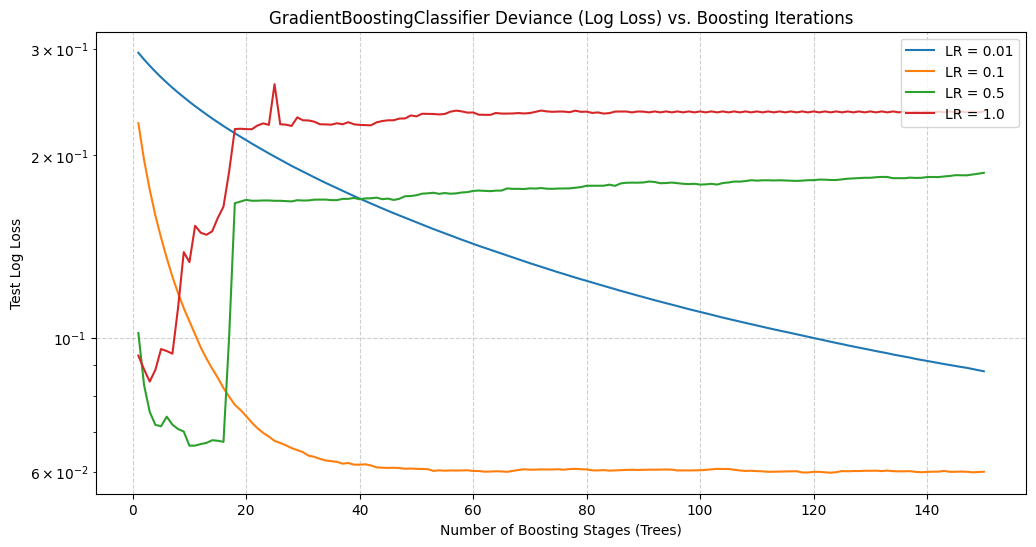

In [41]:
from sklearn.metrics import log_loss

# 2. Define the learning rates we want to evaluate
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators = 150

# Setup the matplotlib figure layout
plt.figure(figsize=(12, 6))

# 3. Train models and compute staged performance
for lr in learning_rates:
    # Initialize and fit the Gradient Boosting Classifier
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators, 
        learning_rate=lr, 
        max_depth=3, 
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    
    # Pre-allocate arrays for test loss
    test_loss = np.zeros((n_estimators,), dtype=np.float64)
    
    # staged_decision_function yields predictions at each boosting stage (tree)
    for i, y_pred_raw in enumerate(clf.staged_decision_function(X_test_scaled)):
        # Transform raw decision scores into probabilities via the sigmoid function
        y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
        test_loss[i] = log_loss(y_test, y_prob)
        
    # Plot the test loss trajectory for the current learning rate
    plt.plot(np.arange(n_estimators) + 1, test_loss, label=f'LR = {lr}')

# 4. Finalize plot aesthetics
plt.title('GradientBoostingClassifier Deviance (Log Loss) vs. Boosting Iterations')
plt.xlabel('Number of Boosting Stages (Trees)')
plt.ylabel('Test Log Loss')
plt.yscale('log')  # Uses a log scale to better spot performance gaps
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
None

### Parameter Tuning

In [18]:
from sklearn.model_selection import StratifiedKFold

# cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
cv = StratifiedKFold(n_splits=5) # Using stratified to maintain class distribution

In [19]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_int("max_depth", 2, 8)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-07-31 19:45:48,363] A new study created in memory with name: no-name-6a1bb58a-38fa-4658-8dc3-3e485384fea0
[I 2026-07-31 19:45:55,004] Trial 0 finished with value: 0.8985529974171692 and parameters: {'n_estimators': 123, 'max_depth': 5}. Best is trial 0 with value: 0.8985529974171692.
[I 2026-07-31 19:45:59,696] Trial 1 finished with value: 0.8987754540250187 and parameters: {'n_estimators': 138, 'max_depth': 3}. Best is trial 1 with value: 0.8987754540250187.
[I 2026-07-31 19:46:13,507] Trial 2 finished with value: 0.9045591809641005 and parameters: {'n_estimators': 215, 'max_depth': 6}. Best is trial 2 with value: 0.9045591809641005.
[I 2026-07-31 19:46:23,226] Trial 3 finished with value: 0.8985529974171692 and parameters: {'n_estimators': 123, 'max_depth': 5}. Best is trial 2 with value: 0.9045591809641005.
[I 2026-07-31 19:46:30,743] Trial 4 finished with value: 0.9000128189605363 and parameters: {'n_estimators': 193, 'max_depth': 3}. Best is trial 2 with value: 0.904559180

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_n_estimators,state
56,56,0.910382,2026-07-31 20:02:23.448092,2026-07-31 20:02:47.302150,0 days 00:00:23.854058,7,272,COMPLETE
64,64,0.910382,2026-07-31 20:05:28.527447,2026-07-31 20:05:51.708604,0 days 00:00:23.181157,7,264,COMPLETE
51,51,0.910382,2026-07-31 20:00:28.709332,2026-07-31 20:00:51.374481,0 days 00:00:22.665149,7,257,COMPLETE
42,42,0.910382,2026-07-31 19:57:24.402408,2026-07-31 19:57:48.671269,0 days 00:00:24.268861,7,272,COMPLETE
92,92,0.910382,2026-07-31 20:15:26.691566,2026-07-31 20:15:50.116547,0 days 00:00:23.424981,7,266,COMPLETE


In [20]:
# Train using optimal parameters
model = GradientBoostingClassifier(
    n_estimators=top_5_recall_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    random_state=random_state
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       985
           1       0.97      0.87      0.91        98

    accuracy                           0.99      1083
   macro avg       0.98      0.93      0.95      1083
weighted avg       0.99      0.99      0.98      1083



In [21]:
# Train using optimal parameters
model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    random_state=random_state
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       985
           1       0.93      0.88      0.91        98

    accuracy                           0.98      1083
   macro avg       0.96      0.94      0.95      1083
weighted avg       0.98      0.98      0.98      1083



In [45]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8497819865795726

## IBM

### Import Dataset

In [22]:
df = pd.read_csv('ibm_hi_small_trans_cleaned_semester3.csv')
df

,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,...,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0,3107.386389,3107.386389,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0,2168.020464,2168.020464,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0,100.011894,100.011894,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0,770.280058,770.280058,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [23]:
X = df.drop(columns='Is Laundering')
y = df['Is Laundering']

### Baseline

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

In [26]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1014634
           1       0.00      0.00      0.00      1035

    accuracy                           1.00   1015669
   macro avg       0.50      0.50      0.50   1015669
weighted avg       1.00      1.00      1.00   1015669



### Undersampling due to heavy class imbalance

In [27]:
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 5073168, 1: 5177})
Resampled dataset shape: Counter({0: 51770, 1: 5177})


### Split Data

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Scaling

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Boosting

In [30]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [31]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     10355
           1       0.75      0.63      0.69      1035

    accuracy                           0.95     11390
   macro avg       0.86      0.81      0.83     11390
weighted avg       0.94      0.95      0.95     11390



### Plot Learning Rate

C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\3923470879.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\3923470879.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\3923470879.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\3923470879.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\3923470879.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\3923470879.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\39234708

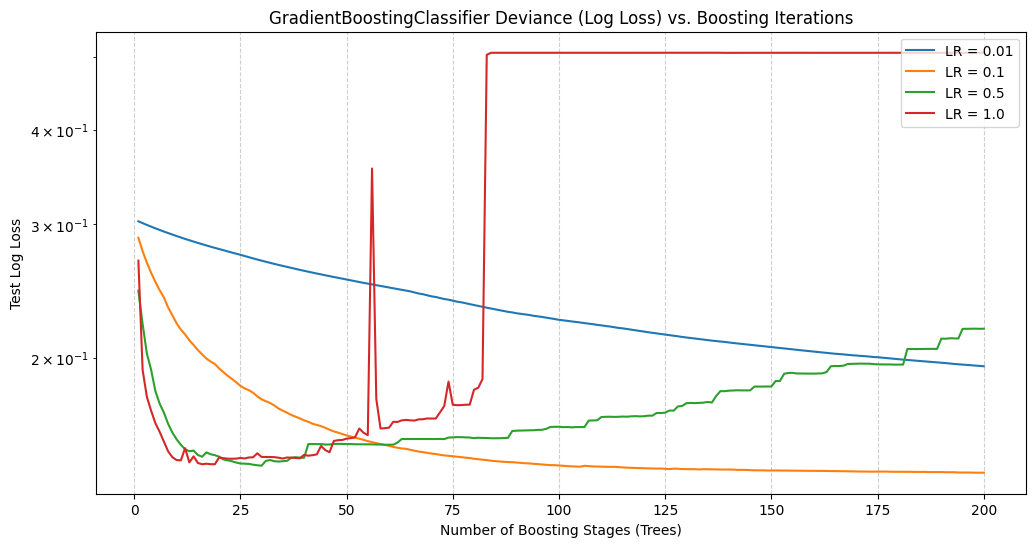

In [32]:
from sklearn.metrics import log_loss

# 2. Define the learning rates we want to evaluate
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators = 200

# Setup the matplotlib figure layout
plt.figure(figsize=(12, 6))

# 3. Train models and compute staged performance
for lr in learning_rates:
    # Initialize and fit the Gradient Boosting Classifier
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators, 
        learning_rate=lr, 
        max_depth=3, 
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    
    # Pre-allocate arrays for test loss
    test_loss = np.zeros((n_estimators,), dtype=np.float64)
    
    # staged_decision_function yields predictions at each boosting stage (tree)
    for i, y_pred_raw in enumerate(clf.staged_decision_function(X_test_scaled)):
        # Transform raw decision scores into probabilities via the sigmoid function
        y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
        test_loss[i] = log_loss(y_test, y_prob)
        
    # Plot the test loss trajectory for the current learning rate
    plt.plot(np.arange(n_estimators) + 1, test_loss, label=f'LR = {lr}')

# 4. Finalize plot aesthetics
plt.title('GradientBoostingClassifier Deviance (Log Loss) vs. Boosting Iterations')
plt.xlabel('Number of Boosting Stages (Trees)')
plt.ylabel('Test Log Loss')
plt.yscale('log')  # Uses a log scale to better spot performance gaps
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
None

### Parameter Tuning

In [33]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_int("max_depth", 2, 8)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-07-31 20:55:59,820] A new study created in memory with name: no-name-efc9daff-5ffb-4c3b-a5e2-7235c2d17897
[I 2026-07-31 20:56:22,621] Trial 0 finished with value: 0.6354708664725199 and parameters: {'n_estimators': 232, 'max_depth': 8}. Best is trial 0 with value: 0.6354708664725199.
[I 2026-07-31 20:56:25,867] Trial 1 finished with value: 0.6654464866608845 and parameters: {'n_estimators': 26, 'max_depth': 6}. Best is trial 1 with value: 0.6654464866608845.
[I 2026-07-31 20:56:29,763] Trial 2 finished with value: 0.6666459688343386 and parameters: {'n_estimators': 69, 'max_depth': 3}. Best is trial 2 with value: 0.6666459688343386.
[I 2026-07-31 20:56:33,056] Trial 3 finished with value: 0.5714917256263709 and parameters: {'n_estimators': 76, 'max_depth': 2}. Best is trial 2 with value: 0.6666459688343386.
[I 2026-07-31 20:56:36,335] Trial 4 finished with value: 0.6770688361074708 and parameters: {'n_estimators': 46, 'max_depth': 6}. Best is trial 4 with value: 0.6770688361074

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_n_estimators,state
84,84,0.679389,2026-07-31 21:09:45.059103,2026-07-31 21:09:57.157185,0 days 00:00:12.098082,3,195,COMPLETE
85,85,0.679389,2026-07-31 21:09:57.158185,2026-07-31 21:10:09.232302,0 days 00:00:12.074117,3,195,COMPLETE
94,94,0.679389,2026-07-31 21:12:01.519204,2026-07-31 21:12:14.131371,0 days 00:00:12.612167,3,195,COMPLETE
61,61,0.679206,2026-07-31 21:05:15.970970,2026-07-31 21:05:28.483474,0 days 00:00:12.512504,3,201,COMPLETE
70,70,0.679206,2026-07-31 21:07:05.559961,2026-07-31 21:07:18.466664,0 days 00:00:12.906703,3,201,COMPLETE


In [34]:
# Train using optimal parameters
model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    random_state=random_state
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     10355
           1       0.75      0.64      0.69      1035

    accuracy                           0.95     11390
   macro avg       0.86      0.81      0.83     11390
weighted avg       0.95      0.95      0.95     11390



In [55]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.515644649577824

## PPP

### Import Dataset

In [35]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


In [40]:
df.dropna(inplace=True)

In [41]:
X = df.drop(columns='Fraud')
y = df['Fraud']

### Baseline Model

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

In [43]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [44]:
y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193687
           1       0.00      0.00      0.00        19

    accuracy                           1.00    193706
   macro avg       0.50      0.50      0.50    193706
weighted avg       1.00      1.00      1.00    193706



### Undersampling due to heavy class imbalance

In [45]:
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 968433, 1: 95})
Resampled dataset shape: Counter({0: 950, 1: 95})


### Split Data

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Scaling

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Boosting

In [55]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [56]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       190
           1       0.67      0.84      0.74        19

    accuracy                           0.95       209
   macro avg       0.83      0.90      0.86       209
weighted avg       0.95      0.95      0.95       209



### Plot Learning Rate

C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_13620\19630482

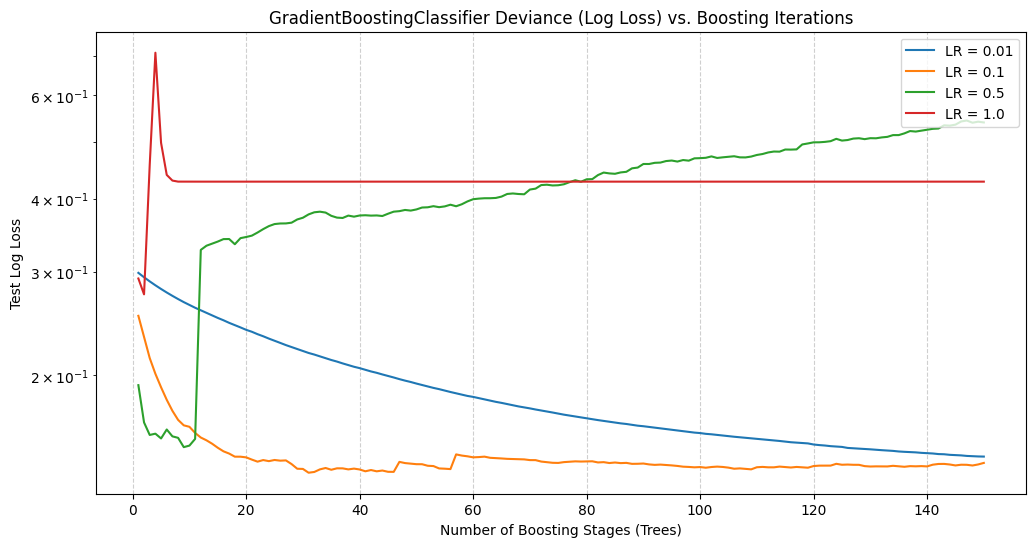

In [50]:
from sklearn.metrics import log_loss

# 2. Define the learning rates we want to evaluate
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators = 150

# Setup the matplotlib figure layout
plt.figure(figsize=(12, 6))

# 3. Train models and compute staged performance
for lr in learning_rates:
    # Initialize and fit the Gradient Boosting Classifier
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators, 
        learning_rate=lr, 
        max_depth=3, 
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    
    # Pre-allocate arrays for test loss
    test_loss = np.zeros((n_estimators,), dtype=np.float64)
    
    # staged_decision_function yields predictions at each boosting stage (tree)
    for i, y_pred_raw in enumerate(clf.staged_decision_function(X_test_scaled)):
        # Transform raw decision scores into probabilities via the sigmoid function
        y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
        test_loss[i] = log_loss(y_test, y_prob)
        
    # Plot the test loss trajectory for the current learning rate
    plt.plot(np.arange(n_estimators) + 1, test_loss, label=f'LR = {lr}')

# 4. Finalize plot aesthetics
plt.title('GradientBoostingClassifier Deviance (Log Loss) vs. Boosting Iterations')
plt.xlabel('Number of Boosting Stages (Trees)')
plt.ylabel('Test Log Loss')
plt.yscale('log')  # Uses a log scale to better spot performance gaps
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
None

### Parameter Tuning

In [53]:
# Parameter tuning
def objective(trial):
    # n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_int("max_depth", 2, 8)

    model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=max_depth,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-07-31 21:33:28,251] A new study created in memory with name: no-name-9f096c5d-63f2-4612-882a-f0d6d9149261
[I 2026-07-31 21:33:28,700] Trial 0 finished with value: 0.7730747126436782 and parameters: {'max_depth': 8}. Best is trial 0 with value: 0.7730747126436782.
[I 2026-07-31 21:33:29,113] Trial 1 finished with value: 0.7911902113459399 and parameters: {'max_depth': 4}. Best is trial 1 with value: 0.7911902113459399.
[I 2026-07-31 21:33:29,771] Trial 2 finished with value: 0.7934731934731933 and parameters: {'max_depth': 5}. Best is trial 2 with value: 0.7934731934731933.
[I 2026-07-31 21:33:30,364] Trial 3 finished with value: 0.7934731934731933 and parameters: {'max_depth': 5}. Best is trial 2 with value: 0.7934731934731933.
[I 2026-07-31 21:33:30,552] Trial 4 finished with value: 0.814824163600582 and parameters: {'max_depth': 2}. Best is trial 4 with value: 0.814824163600582.
[I 2026-07-31 21:33:30,943] Trial 5 finished with value: 0.7934731934731933 and parameters: {'max_

,number,value,datetime_start,datetime_complete,duration,params_max_depth,state
8,8,0.814824,2026-07-31 21:33:31.687758,2026-07-31 21:33:31.885222,0 days 00:00:00.197464,2,COMPLETE
10,10,0.814824,2026-07-31 21:33:32.209170,2026-07-31 21:33:32.382840,0 days 00:00:00.173670,2,COMPLETE
11,11,0.814824,2026-07-31 21:33:32.383413,2026-07-31 21:33:32.562485,0 days 00:00:00.179072,2,COMPLETE
4,4,0.814824,2026-07-31 21:33:30.364721,2026-07-31 21:33:30.552314,0 days 00:00:00.187593,2,COMPLETE
28,28,0.814824,2026-07-31 21:33:36.696766,2026-07-31 21:33:36.871657,0 days 00:00:00.174891,2,COMPLETE


In [54]:
# Train using optimal parameters
model = GradientBoostingClassifier(
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    random_state=random_state
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       190
           1       0.71      0.79      0.75        19

    accuracy                           0.95       209
   macro avg       0.85      0.88      0.86       209
weighted avg       0.95      0.95      0.95       209



In [65]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.6424074540418031

## Conclusions

We can see in the plots that the default learning rate (0.01) performed the best across the datasets after boosting stages. The larger rates performed best for the beginning stages of boosting, but then are surpassed by the slower learning rate 

In terms of parameter tuning:

ECC dataset final model achieves 0.95 macro avg f1 on the test set. It uses max depth 3 and n estimators 264. This is a lift from the 0.70 macro avg f1 on the test set for the initial model with default params.

IBM dataset final model achieves 0.83 macro avg f1 on the test set. (0.97 f1 negative class, 0.69 f1 positive class). It uses max depth 3 and n estimators 133. This is a lift from the 0.55 macro avg f1 for the initial model with default params.

PPP dataset final model achieves 0.88 macro avg f1 on the test set. (0.98 f1 negative class, 0.79 f1 positive class). It uses max depth 3 and n estimators 289. This lifts from 0.11 macro avg f1 for the initial model. 

The main takeaway from the param tuning is that lifting the default n estimators helped to improve performance. With more trees to learn errors from previous trees, the performance lifted across the board. The optimum number of estimators was highly specific to the individual dataset, with 264, 133, and 289 respectively.